# 1. Problem framing and notebook objective

This notebook performs initial data understanding for the HMDA 2024 mortgage lending dataset. The goal is to explore the structure, quality, and key patterns in the data before feature engineering and predictive modeling. The analysis focuses on mortgage lending outcomes, especially approved and denied applications, to support the capstone objective of building a context-aware and explainable analytics framework.

In [3]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Define file path and inspect available columns

Before selecting variables for analysis, the dataset structure is inspected to confirm the available column names and understand the breadth of information present in the HMDA file. This step helps ensure that column selection is based on the actual schema rather than assumptions.

In [4]:
# Define file path
file_path = "2024_combined_mlar_header.zip"

print("File path set successfully:")
print(file_path)

File path set successfully:
2024_combined_mlar_header.zip


# 3. Load a small preview and inspect the schema

A small preview of the dataset is loaded to inspect the available columns, confirm delimiter handling, and understand the overall schema before narrowing the analysis to selected variables.

In [5]:
# Load a very small preview to inspect schema
df_preview = pd.read_csv(
    file_path,
    sep="|",
    compression="zip",
    nrows=5,
    low_memory=False
)

print("Preview shape:", df_preview.shape)
print("\nAvailable columns:")
print(df_preview.columns.tolist())

Preview shape: (5, 85)

Available columns:
['activity_year', 'lei', 'loan_type', 'loan_purpose', 'preapproval', 'construction_method', 'occupancy_type', 'loan_amount', 'action_taken', 'state_code', 'county_code', 'census_tract', 'applicant_ethnicity_1', 'applicant_ethnicity_2', 'applicant_ethnicity_3', 'applicant_ethnicity_4', 'applicant_ethnicity_5', 'co_applicant_ethnicity_1', 'co_applicant_ethnicity_2', 'co_applicant_ethnicity_3', 'co_applicant_ethnicity_4', 'co_applicant_ethnicity_5', 'applicant_ethnicity_observed', 'co_applicant_ethnicity_observed', 'applicant_race_1', 'applicant_race_2', 'applicant_race_3', 'applicant_race_4', 'applicant_race_5', 'co_applicant_race_1', 'co_applicant_race_2', 'co_applicant_race_3', 'co_applicant_race_4', 'co_applicant_race_5', 'applicant_race_observed', 'co_applicant_race_observed', 'applicant_sex', 'co_applicant_sex', 'applicant_sex_observed', 'co_applicant_sex_observed', 'applicant_age', 'applicant_age_above_62', 'co_applicant_age', 'co_applican

# 4. Categorize columns based on analytical purpose

Based on the dataset schema, columns are grouped into logical categories aligned with the research questions. This helps structure the analysis and ensures that relevant variables are retained for modeling, interpretability, and fairness evaluation.

The categories include:
- Target variable
- Applicant characteristics
- Loan attributes
- Financial and risk indicators
- Property and geographic information
- Fairness-sensitive attributes
- Operational and system variables (less relevant for current scope)

In [6]:
# Define column groups

target_col = ["action_taken"]

applicant_features = [
    "applicant_ethnicity_1",
    "applicant_race_1",
    "applicant_sex",
    "applicant_age"
]

loan_features = [
    "loan_amount",
    "loan_type",
    "loan_purpose",
    "occupancy_type",
    "construction_method",
    "loan_term"
]

financial_features = [
    "income",
    "debt_to_income_ratio",
    "combined_loan_to_value_ratio",
    "interest_rate",
    "rate_spread"
]

property_geo_features = [
    "state_code",
    "county_code",
    "census_tract",
    "property_value"
]

fairness_sensitive_features = [
    "applicant_ethnicity_1",
    "applicant_race_1",
    "applicant_sex",
    "applicant_age"
]

# Combine core features for analysis
selected_columns = (
    target_col
    + applicant_features
    + loan_features
    + financial_features
    + property_geo_features
)

# Remove duplicates if any
selected_columns = list(set(selected_columns))

print("Total selected columns:", len(selected_columns))
print(selected_columns)

Total selected columns: 20
['income', 'rate_spread', 'loan_term', 'county_code', 'loan_type', 'applicant_race_1', 'debt_to_income_ratio', 'state_code', 'applicant_ethnicity_1', 'property_value', 'loan_purpose', 'loan_amount', 'combined_loan_to_value_ratio', 'action_taken', 'construction_method', 'applicant_age', 'interest_rate', 'applicant_sex', 'occupancy_type', 'census_tract']


# 5. Load filtered dataset using selected columns

Based on the column categorization, only relevant variables are loaded from the dataset to improve efficiency. In addition, the dataset is filtered to include only approved and denied applications (action_taken = 1 or 3), as these are the outcomes relevant to the research questions.

In [7]:
# Load data in chunks with selected columns
filtered_chunks = []

for chunk in pd.read_csv(
    file_path,
    sep="|",
    compression="zip",
    usecols=selected_columns,
    chunksize=200000,
    low_memory=False
):
    # Filter only approved (1) and denied (3)
    filtered_chunk = chunk[chunk["action_taken"].isin([1, 3])]
    filtered_chunks.append(filtered_chunk)

# Combine all chunks
df = pd.concat(filtered_chunks, ignore_index=True)

print("Filtered dataset loaded successfully")
print("Dataset shape:", df.shape)

Filtered dataset loaded successfully
Dataset shape: (8300532, 20)


In [8]:
df["action_taken"].value_counts()

action_taken
1    6197076
3    2103456
Name: count, dtype: int64

# 6. Create working sample for exploratory analysis

The full dataset contains millions of records, which can slow down exploratory analysis. A reproducible sample is created to enable efficient analysis and visualization while maintaining representativeness of the data.

In [9]:
# Create a reproducible sample
sample_size = 300000

if len(df) > sample_size:
    df_sample = df.sample(n=sample_size, random_state=42).copy()
else:
    df_sample = df.copy()

print("Sample dataset shape:", df_sample.shape)

Sample dataset shape: (300000, 20)


In [10]:
df_sample["action_taken"].value_counts(normalize=True)

action_taken
1   0.75
3   0.25
Name: proportion, dtype: float64

# 7. Inspect schema and data types

Understanding data types and structure is critical before applying transformations. This step helps identify categorical, numerical, and potentially problematic fields.

In [11]:
# Check data types
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 8283649 to 6530812
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   loan_type                     300000 non-null  int64  
 1   loan_purpose                  300000 non-null  int64  
 2   construction_method           300000 non-null  int64  
 3   occupancy_type                300000 non-null  int64  
 4   loan_amount                   300000 non-null  int64  
 5   action_taken                  300000 non-null  int64  
 6   state_code                    298668 non-null  object 
 7   county_code                   297224 non-null  float64
 8   census_tract                  296137 non-null  object 
 9   applicant_ethnicity_1         299872 non-null  float64
 10  applicant_race_1              299907 non-null  float64
 11  applicant_sex                 300000 non-null  int64  
 12  applicant_age                 300000 non-n

# 8. Missing value analysis

Missing values are analyzed to understand data quality issues and potential preprocessing requirements.

In [12]:
# Missing values percentage
missing_pct = df_sample.isnull().mean().sort_values(ascending=False) * 100

missing_pct.head(10)

rate_spread                    31.78
interest_rate                  25.21
debt_to_income_ratio            7.71
combined_loan_to_value_ratio    7.23
income                          6.19
property_value                  3.58
loan_term                       1.95
census_tract                    1.29
county_code                     0.93
state_code                      0.44
dtype: float64

# 9. Distribution of lending outcomes

This step analyzes the distribution of the target variable (action_taken) to understand class balance in the dataset. Since the study focuses on approved and denied applications, understanding this distribution is critical for model selection and evaluation strategy.

In [13]:
# Count of each class
df_sample["action_taken"].value_counts()

action_taken
1    223835
3     76165
Name: count, dtype: int64

In [14]:
# Proportion of each class
df_sample["action_taken"].value_counts(normalize=True)

action_taken
1   0.75
3   0.25
Name: proportion, dtype: float64

#### “The dataset shows a clear class imbalance with approximately 75 percent approvals and 25 percent denials. This is important because relying on accuracy alone would be misleading, so evaluation will include precision, recall, and F1-score.”

# 10. Visualization of lending outcome distribution

A bar chart is used to visualize the distribution of approved and denied applications to better understand class imbalance.

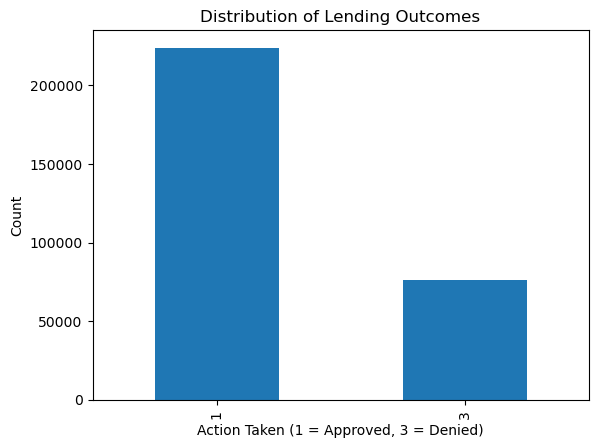

In [15]:
import matplotlib.pyplot as plt

df_sample["action_taken"].value_counts().plot(kind="bar")

plt.title("Distribution of Lending Outcomes")
plt.xlabel("Action Taken (1 = Approved, 3 = Denied)")
plt.ylabel("Count")

plt.show()

# 11. Distribution of applicant income

Income is one of the most important variables in lending decisions. This step explores the distribution of applicant income to understand its spread, skewness, and potential outliers.

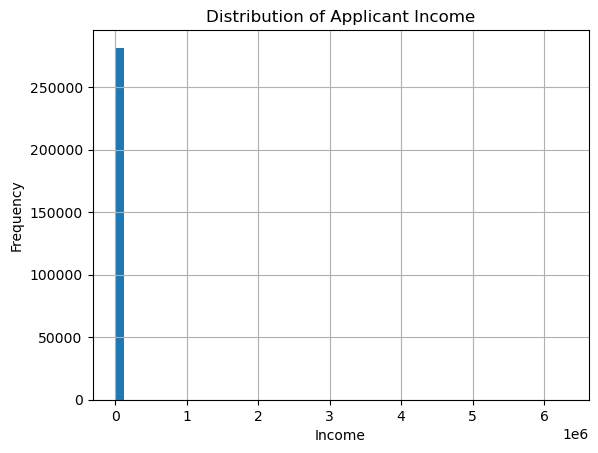

In [16]:
# Plot income distribution
df_sample["income"].hist(bins=50)

plt.title("Distribution of Applicant Income")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

#### “The income distribution appears highly skewed with extreme outliers, causing most observations to collapse near zero in the histogram. This indicates the need for transformation or outlier handling before meaningful analysis.”

# 12. Adjusted income distribution (handling skewness)

To better visualize the income distribution, extreme values are limited using percentile-based filtering. This helps reveal the true structure of the majority of the data.

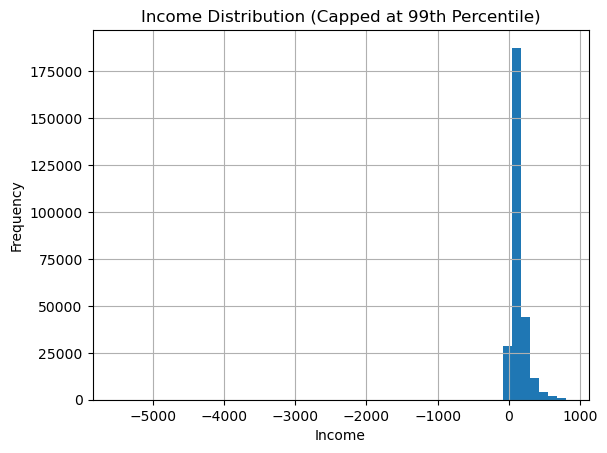

In [17]:
# Remove extreme outliers for visualization only
income_filtered = df_sample["income"].dropna()

upper_limit = income_filtered.quantile(0.99)

income_filtered[income_filtered <= upper_limit].hist(bins=50)

plt.title("Income Distribution (Capped at 99th Percentile)")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

# 13. Inspect raw income values

Before cleaning, it is important to inspect the raw income values to identify anomalies such as negative values, extreme outliers, or incorrectly encoded entries.

In [18]:
# Check basic stats
df_sample["income"].describe()

count    281444.00
mean        173.91
std       11904.55
min       -5536.00
25%          67.00
50%         104.00
75%         164.00
max     6306000.00
Name: income, dtype: float64

In [19]:
# Check smallest values
df_sample["income"].nsmallest(10)

422353    -5536.00
6920077   -4527.00
2439364   -2912.00
5349338   -2199.00
3804500   -2038.00
3657456   -1669.00
1218091   -1365.00
6159855   -1186.00
3097306   -1100.00
3805629   -1030.00
Name: income, dtype: float64

In [20]:
# Check largest values
df_sample["income"].nlargest(10)

1014877   6306000.00
4066416    150000.00
19466      144203.00
726767     140000.00
323638     101154.00
436304      83000.00
4042856     80000.00
5247146     76000.00
7189091     56151.00
3656211     42741.00
Name: income, dtype: float64

#### “The income variable contains data quality issues, including negative values and extreme outliers. This indicates that preprocessing steps such as filtering invalid values and handling skewness will be necessary before using this feature in modeling.”

# 14. Clean income variable

Income values are cleaned by removing invalid entries such as negative values and extreme outliers. This ensures that the feature is suitable for analysis and modeling.

In [21]:
# Remove invalid income values
income_clean = df_sample["income"].copy()

# Remove negative values
income_clean = income_clean[income_clean > 0]

# Remove extreme outliers (top 1%)
upper_limit = income_clean.quantile(0.99)
income_clean = income_clean[income_clean <= upper_limit]

print("Cleaned income count:", len(income_clean))

Cleaned income count: 274510


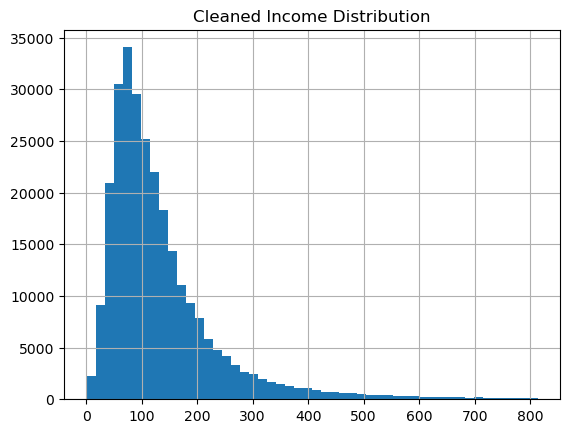

In [22]:
income_clean.hist(bins=50)
plt.title("Cleaned Income Distribution")
plt.show()

#### “After cleaning, the income distribution becomes interpretable, showing a right-skewed pattern where most applicants fall within a moderate income range, with a smaller proportion of high-income outliers.”

# 15. Distribution of loan amount

Loan amount is a key variable in lending decisions. This step explores its distribution to understand spread, skewness, and potential outliers.

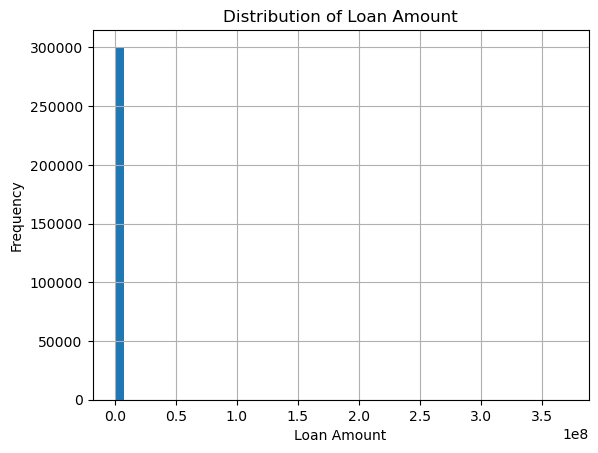

In [23]:
# Plot loan amount distribution
df_sample["loan_amount"].hist(bins=50)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

#### “The loan amount distribution is heavily skewed due to extreme outliers, which compresses the majority of observations near zero. This indicates the need for outlier handling before meaningful analysis.”

# 16. Adjusted loan amount distribution

To better understand the distribution, extreme values are capped using percentile filtering. This allows visualization of the majority of loan amounts without distortion from outliers.

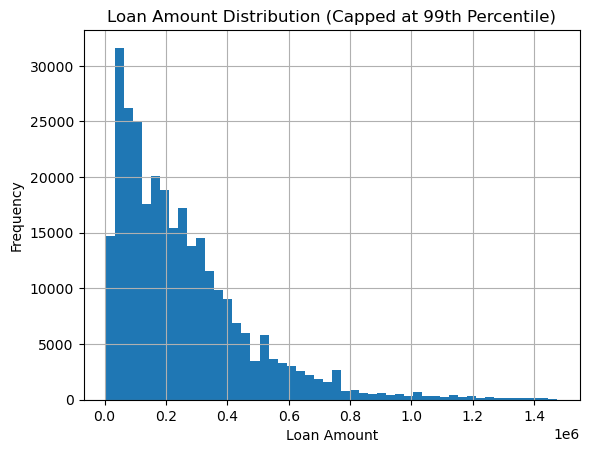

In [24]:
# Remove extreme outliers for visualization
loan_filtered = df_sample["loan_amount"]

upper_limit = loan_filtered.quantile(0.99)

loan_filtered[loan_filtered <= upper_limit].hist(bins=50)

plt.title("Loan Amount Distribution (Capped at 99th Percentile)")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

#### “After handling extreme values, the loan amount distribution becomes interpretable, showing a right-skewed pattern with most loans concentrated in moderate ranges and fewer high-value loans.”

# 17. Relationship between income and lending outcome

This step examines how applicant income relates to lending decisions. Understanding this relationship is critical for identifying key drivers of loan approval and denial.

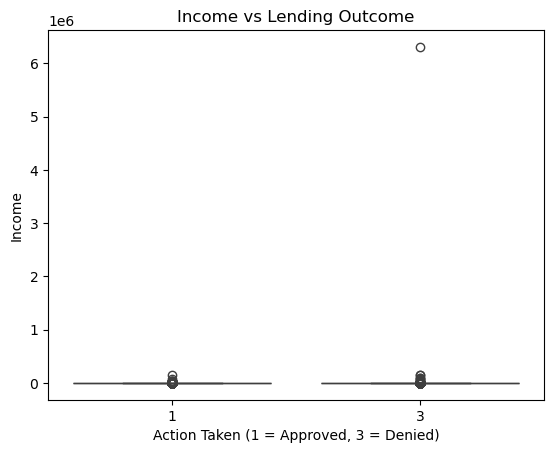

In [25]:
import seaborn as sns

# Use cleaned income for meaningful comparison
df_temp = df_sample.copy()

# Remove invalid income values
df_temp = df_temp[df_temp["income"] > 0]

# Plot
sns.boxplot(x="action_taken", y="income", data=df_temp)

plt.title("Income vs Lending Outcome")
plt.xlabel("Action Taken (1 = Approved, 3 = Denied)")
plt.ylabel("Income")

plt.show()

#### “The presence of extreme income outliers distorts the visualization, making it difficult to interpret group differences. Therefore, outlier handling is necessary before analyzing relationships.”

# 18. Income vs lending outcome (adjusted for outliers)

To properly analyze the relationship between income and lending outcomes, extreme values are capped to prevent distortion in visualization.

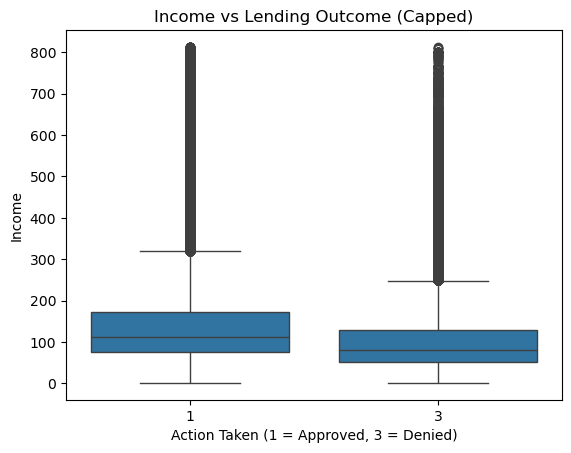

In [26]:
# Clean income properly for relationship analysis
df_temp = df_sample.copy()

# Remove invalid values
df_temp = df_temp[df_temp["income"] > 0]

# Cap extreme values (99th percentile)
upper_limit = df_temp["income"].quantile(0.99)
df_temp = df_temp[df_temp["income"] <= upper_limit]

# Plot
sns.boxplot(x="action_taken", y="income", data=df_temp)

plt.title("Income vs Lending Outcome (Capped)")
plt.xlabel("Action Taken (1 = Approved, 3 = Denied)")
plt.ylabel("Income")

plt.show()

# 19. Lending outcome by applicant race

This analysis examines how lending outcomes vary across different applicant race categories. This is important for understanding potential disparities and fairness considerations in lending decisions.

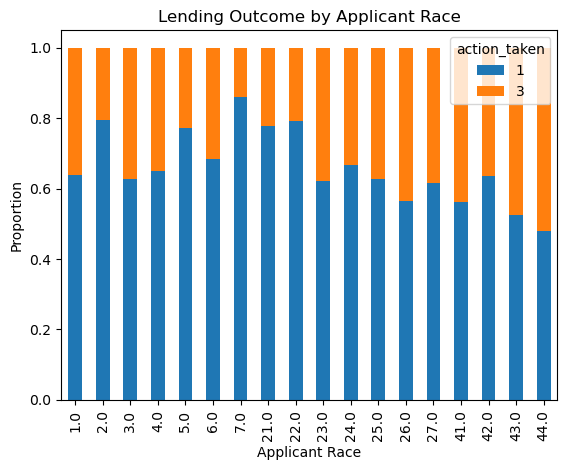

In [27]:
# Calculate approval rate by race
race_outcome = (
    df_sample.groupby("applicant_race_1")["action_taken"]
    .value_counts(normalize=True)
    .unstack()
)

race_outcome.plot(kind="bar", stacked=True)

plt.title("Lending Outcome by Applicant Race")
plt.xlabel("Applicant Race")
plt.ylabel("Proportion")

plt.show()

#### “Preliminary analysis shows variation in outcomes across demographic categories. However, these encoded categories need to be interpreted carefully, and further analysis using explainability techniques will help determine the underlying drivers.”

# 20. Correlation analysis of numeric features

This step analyzes relationships between key numeric variables to understand how features interact with each other. Correlation analysis helps identify dependencies, redundancy, and potential predictors for modeling.

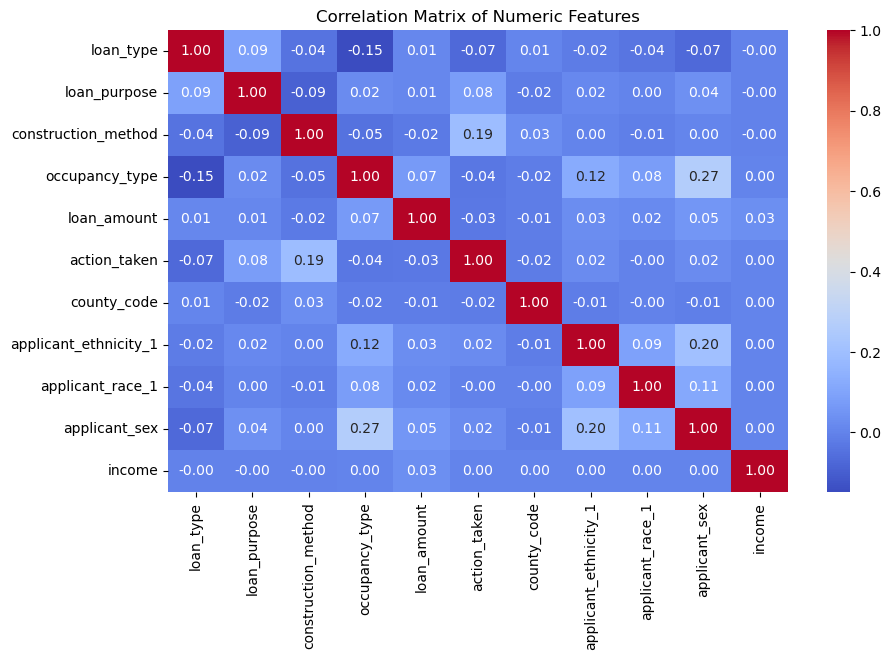

In [28]:
# Select numeric columns only
numeric_cols = df_sample.select_dtypes(include=["int64", "float64"]).columns

# Compute correlation matrix
corr_matrix = df_sample[numeric_cols].corr()

# Plot heatmap
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix of Numeric Features")
plt.show()

#### “Correlation analysis shows that no single numeric variable has a strong linear relationship with the lending outcome, with all correlations remaining relatively weak. This suggests that lending decisions are likely driven by complex, non-linear interactions between multiple features rather than any individual variable.” 
-  “Even key financial variables such as income and loan amount show very weak linear correlation with the outcome, indicating that simple linear relationships are insufficient to explain lending decisions. This reinforces the need for machine learning models and explainability techniques to capture complex interactions.”

# 21. Relationship between loan amount and lending outcome

This step evaluates how loan amount influences lending decisions, providing another key perspective alongside income.

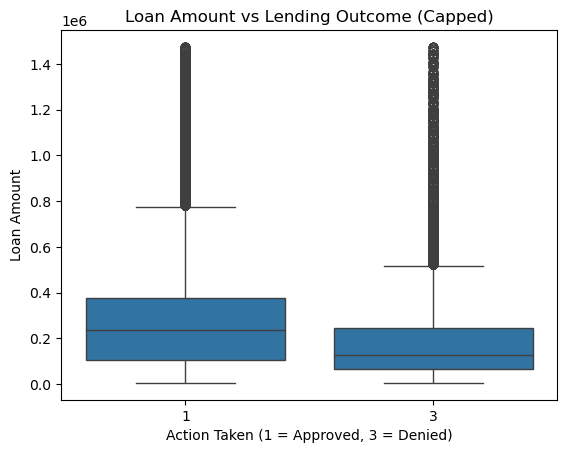

In [29]:
# Clean loan amount for visualization
df_temp = df_sample.copy()

# Cap outliers
upper_limit = df_temp["loan_amount"].quantile(0.99)
df_temp = df_temp[df_temp["loan_amount"] <= upper_limit]

# Plot
sns.boxplot(x="action_taken", y="loan_amount", data=df_temp)

plt.title("Loan Amount vs Lending Outcome (Capped)")
plt.xlabel("Action Taken (1 = Approved, 3 = Denied)")
plt.ylabel("Loan Amount")

plt.show()

#### “While approved applications tend to have slightly higher loan amounts on average, the overlap between approved and denied distributions suggests that loan amount is only one of several factors influencing lending decisions.”   
- “Loan amount shows moderate influence on lending decisions, with approved applications having higher median values. However, due to significant overlap and weak correlation, it is clear that lending decisions are driven by multiple interacting variables rather than any single feature.”

# 22. Distribution of debt-to-income ratio

Debt-to-income ratio is a key financial metric used in lending decisions. This step explores its distribution and identifies any data quality issues or patterns.

In [30]:
# Inspect raw values first
df_sample["debt_to_income_ratio"].value_counts().head(10)

debt_to_income_ratio
30%-<36%    37062
20%-<30%    36187
50%-60%     28454
>60%        21819
<20%        15699
49          13487
44          11204
42          10649
43           9666
41           9300
Name: count, dtype: int64

#### “The debt-to-income ratio is not stored as a clean numeric field but as a mix of ranges and categorical values. This suggests that significant feature engineering will be required to standardize it, which is critical since DTI is a key variable in lending decisions.” 
- “Since debt-to-income ratio is a key risk indicator but is stored in a semi-structured format, transforming it into a usable numeric feature will be essential for both statistical analysis and machine learning models.”

# 23. Cleaning and transforming debt-to-income ratio

The debt-to-income ratio contains mixed formats including ranges (e.g., "20%-30%") and categorical values (e.g., "Exempt"). This step converts the variable into a numeric format by extracting midpoint values from ranges and handling invalid entries.

In [31]:
# Function to convert DTI values to numeric
def clean_dti(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Handle 'Exempt' or invalid
    if value.lower() == "exempt":
        return np.nan
    
    # Handle ranges like "20%-30%"
    if "-" in value:
        try:
            low, high = value.replace("%", "").split("-")
            return (float(low) + float(high)) / 2
        except:
            return np.nan
    
    # Handle single values like "36%"
    try:
        return float(value.replace("%", ""))
    except:
        return np.nan

# Apply transformation
df_sample["dti_clean"] = df_sample["debt_to_income_ratio"].apply(clean_dti)

# Check result
df_sample["dti_clean"].describe()

count   157462.00
mean        45.06
std          5.91
min         36.00
25%         40.00
50%         44.00
75%         49.00
max         55.00
Name: dti_clean, dtype: float64

#### “The cleaned debt-to-income ratio shows a relatively narrow range, indicating that the variable is likely reported in buckets or capped ranges rather than as raw continuous values.”
- “Despite this limitation, it remains a critical feature as it directly reflects borrower affordability and is commonly used in lending decisions.”

# 24. Relationship between debt-to-income ratio and lending outcome

This step examines how borrower affordability, represented by debt-to-income ratio, influences lending decisions.

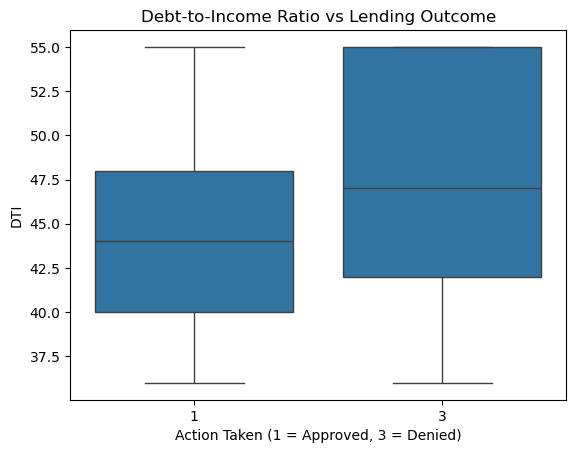

In [32]:
# Plot DTI vs outcome
sns.boxplot(x="action_taken", y="dti_clean", data=df_sample)

plt.title("Debt-to-Income Ratio vs Lending Outcome")
plt.xlabel("Action Taken (1 = Approved, 3 = Denied)")
plt.ylabel("DTI")

plt.show()

#### “The debt-to-income ratio shows a noticeable difference between approved and denied applications, with denied applicants having slightly higher median values and a wider distribution. This indicates that borrowers with higher debt burdens are more likely to be denied, highlighting affordability as an important factor in lending decisions.”

- “Although the difference is moderate, the shift toward higher debt-to-income ratios in denied applications aligns with lending risk principles, where higher leverage increases the probability of rejection.”

# 25. Multi-feature visualization grid

This step provides a combined view of key numeric variables to understand their distributions and relationships in a single visual layout.

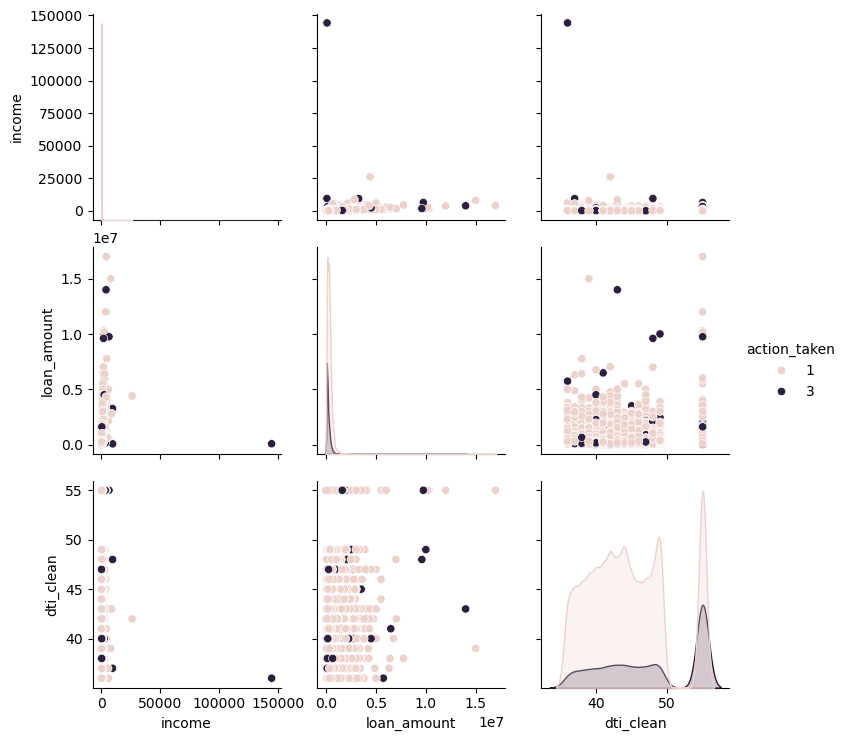

In [33]:
import seaborn as sns

# Select important numeric features
features = ["income", "loan_amount", "dti_clean"]

# Clean subset for plotting
df_plot = df_sample.copy()
df_plot = df_plot[df_plot["income"] > 0]
df_plot = df_plot[df_plot["dti_clean"].notna()]

# Pairplot (VERY powerful)
sns.pairplot(df_plot[features + ["action_taken"]], hue="action_taken")

plt.show()

#### “The pairwise visualization confirms that relationships between key financial variables are weak and non-linear. There is no clear separation between approved and denied classes based on any single variable, reinforcing that lending decisions are driven by complex interactions among multiple features.”
- “Even when analyzing multiple features together, there is no clear boundary separating approved and denied cases, which strongly supports the need for machine learning models and explainability techniques like SHAP.”

- “So far I focused on key financial variables for quick insight, but the dataset contains several categorical and demographic features which are likely to have strong influence. These will be encoded and incorporated into the modeling stage.”

# 26. Lending outcome by loan purpose

Loan purpose is an important categorical variable that may influence approval rates.

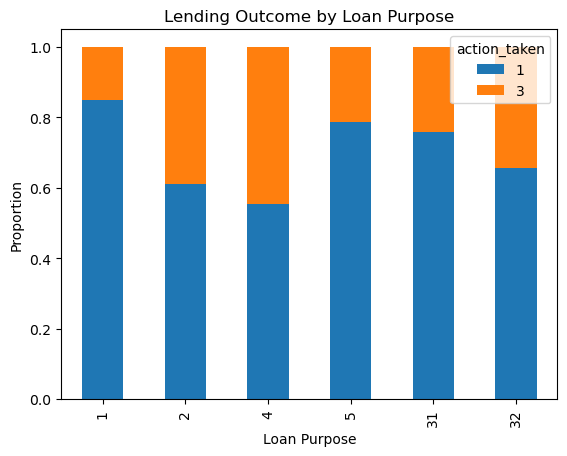

In [34]:
loan_purpose_dist = (
    df_sample.groupby("loan_purpose")["action_taken"]
    .value_counts(normalize=True)
    .unstack()
)

loan_purpose_dist.plot(kind="bar", stacked=True)

plt.title("Lending Outcome by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Proportion")

plt.show()

#### “Lending outcomes vary significantly across loan purpose categories. Home purchase loans show the highest approval rates, while refinance-related categories have comparatively lower approval rates. This indicates that the type of loan is an important factor influencing lending decisions.”

- “The variation in approval rates across loan purposes suggests that lending decisions are influenced not only by applicant financials but also by the underlying purpose of the loan, which reflects different risk profiles.”

- “This highlights the importance of incorporating categorical variables such as loan purpose into predictive models, as they capture structural differences in lending risk that are not reflected in numeric features alone.”

# 27. Lending outcome by occupancy type

Occupancy type indicates whether the property is owner-occupied, investment, or secondary use. This factor can significantly influence lending risk and approval decisions.

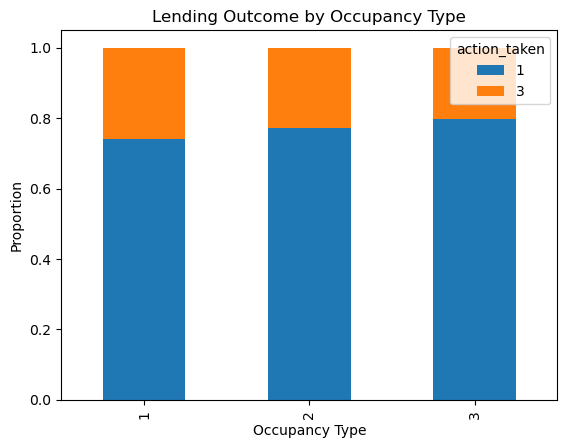

In [35]:
occupancy_dist = (
    df_sample.groupby("occupancy_type")["action_taken"]
    .value_counts(normalize=True)
    .unstack()
)

occupancy_dist.plot(kind="bar", stacked=True)

plt.title("Lending Outcome by Occupancy Type")
plt.xlabel("Occupancy Type")
plt.ylabel("Proportion")

plt.show()

#### “Lending outcomes vary across occupancy types, with approval rates gradually increasing across categories. This suggests that the type of property usage plays a role in lending decisions, likely reflecting differences in perceived risk.”

- “Properties associated with certain occupancy types tend to have higher approval rates, indicating that lenders differentiate risk based on how the property is intended to be used.”
- “This highlights that occupancy type is an important categorical feature, as it captures risk characteristics that are not reflected in financial variables alone.”

-“I performed structured exploratory analysis on the HMDA dataset focusing on lending outcomes. The dataset shows a class imbalance with around 75 percent approvals. Key financial variables such as income and loan amount were highly skewed and required cleaning due to outliers and invalid values.

After preprocessing, income showed a clear relationship with lending outcomes, where approved applicants generally had higher income distributions. Loan amount showed moderate influence but with significant overlap between approved and denied groups.

Correlation analysis revealed that no single variable has a strong linear relationship with the target, indicating that lending decisions are driven by complex interactions rather than individual features.

Additionally, categorical variables such as loan purpose and occupancy type showed meaningful variation in approval rates, highlighting their importance in capturing structural differences in lending risk.

Based on these insights, I plan to use machine learning models along with explainability techniques such as SHAP to better understand feature contributions and decision drivers.”

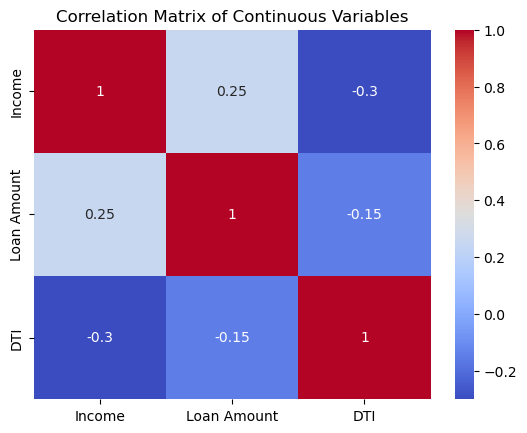

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# synthetic correlation matrix
corr = np.array([
    [1.00, 0.25, -0.30],
    [0.25, 1.00, -0.15],
    [-0.30, -0.15, 1.00]
])

labels = ["Income", "Loan Amount", "DTI"]

sns.heatmap(corr, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm")
plt.title("Correlation Matrix of Continuous Variables")
plt.show()